# Анализ загрузки касс и покупательского потока

**Цель:** на основе транзакционных данных оценить нагрузку на кассы, найти пиковые периоды, оценить потребность в кассирах и проверить, есть ли товары, которые непропорционально часто встречаются на отдельных кассах.

> Данные в notebook полностью синтетические и используются только для демонстрации подхода.


## 1. Подготовка окружения

В анализе используются `pandas` и `NumPy` для подготовки данных, `Matplotlib` для визуализации и `SciPy` для статистических тестов.


In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "demo-data" / "synthetic_transactions.xlsx"
OUTPUT_PATH = PROJECT_ROOT / "output" / "retail_analysis_report.xlsx"

WEEKDAY_ORDER = [
    "Понедельник", "Вторник", "Среда", "Четверг",
    "Пятница", "Суббота", "Воскресенье",
]
WEEKDAY_MAP = dict(enumerate(WEEKDAY_ORDER))
EXPRESS_REGISTER = "Касса 7 (экспресс)"


## 2. Загрузка и проверка данных

Проверяю обязательные поля, типы данных, пропуски и некорректные количества. Такой шаг нужен до любой агрегации, чтобы ошибки в исходнике не искажали показатели.


In [2]:
df = pd.read_excel(DATA_PATH)

required = {"receipt_id", "datetime", "cash_register", "product", "quantity"}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"Отсутствуют обязательные поля: {sorted(missing)}")

df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce").fillna(0).astype(int)
df = df.dropna(subset=["receipt_id", "datetime", "cash_register", "product"])
df = df[df["quantity"] > 0].copy()

print(f"Товарных строк: {len(df):,}")
print(f"Уникальных чеков: {df['receipt_id'].nunique():,}")
print(f"Касс: {df['cash_register'].nunique()}")
print(f"Период: {df['datetime'].min():%d.%m.%Y} — {df['datetime'].max():%d.%m.%Y}")

df.head()


Товарных строк: 61,724
Уникальных чеков: 13,185
Касс: 7
Период: 01.07.2026 — 28.07.2026


,receipt_id,datetime,cash_register,product,quantity
0,R000003,2026-07-01 08:04:28,Касса 1,Чипсы,1
1,R000003,2026-07-01 08:04:28,Касса 1,Макароны,1
2,R000003,2026-07-01 08:04:28,Касса 1,Хлеб,1
3,R000003,2026-07-01 08:04:28,Касса 1,Жевательная резинка,1
4,R000003,2026-07-01 08:04:28,Касса 1,Газированный напиток,1


## 3. Переход от товарных строк к уровню чека

Одна строка исходного набора — товарная позиция. Для анализа очередей и нагрузки нужна единица наблюдения **чек**, поэтому данные агрегируются по `receipt_id`.


In [3]:
checks = (
    df.groupby("receipt_id", as_index=False)
      .agg(
          datetime=("datetime", "min"),
          cash_register=("cash_register", "first"),
          positions=("product", "size"),
          units=("quantity", "sum"),
      )
)

checks["date"] = checks["datetime"].dt.normalize()
checks["hour"] = checks["datetime"].dt.hour
checks["weekday_num"] = checks["datetime"].dt.dayofweek
checks["weekday"] = checks["weekday_num"].map(WEEKDAY_MAP)
checks["weekday"] = pd.Categorical(
    checks["weekday"], categories=WEEKDAY_ORDER, ordered=True
)
checks["period"] = checks["hour"].map(lambda h: f"{h:02d}–{(h + 1) % 24:02d}")

checks.head()


,receipt_id,datetime,cash_register,positions,units,date,hour,weekday_num,weekday,period
0,R000001,2026-07-01 08:25:51,Касса 1,2,4,2026-07-01,8,2,Среда,08–09
1,R000002,2026-07-01 08:38:32,Касса 4,5,6,2026-07-01,8,2,Среда,08–09
2,R000003,2026-07-01 08:04:28,Касса 1,5,5,2026-07-01,8,2,Среда,08–09
3,R000004,2026-07-01 08:16:46,Касса 4,6,6,2026-07-01,8,2,Среда,08–09
4,R000005,2026-07-01 08:07:33,Касса 5,2,2,2026-07-01,8,2,Среда,08–09


## 4. Нагрузка по кассам

Сравниваю количество чеков, товарных позиций и параметры корзины. Это позволяет увидеть кассы с высокой пропускной нагрузкой и кассы с более тяжёлыми корзинами.


In [4]:
cashier_summary = (
    checks.groupby("cash_register", as_index=False)
      .agg(
          receipts=("receipt_id", "nunique"),
          product_positions=("positions", "sum"),
          average_basket=("positions", "mean"),
          median_basket=("positions", "median"),
          p90_basket=("positions", lambda x: x.quantile(0.90)),
          max_basket=("positions", "max"),
      )
      .sort_values("product_positions", ascending=False)
      .reset_index(drop=True)
)

cashier_summary.insert(0, "load_rank", range(1, len(cashier_summary) + 1))
cashier_summary[["average_basket", "median_basket", "p90_basket"]] = (
    cashier_summary[["average_basket", "median_basket", "p90_basket"]].round(2)
)

cashier_summary


,load_rank,cash_register,receipts,product_positions,average_basket,median_basket,p90_basket,max_basket
0,1,Касса 6,2347,11581,4.93,4.00,9.00,22
1,2,Касса 5,2022,10052,4.97,4.00,9.00,19
2,3,Касса 4,1946,9648,4.96,4.00,9.00,25
3,4,Касса 1,1627,8252,5.07,5.00,9.00,19
4,5,Касса 2,1683,8168,4.85,4.00,9.00,19
5,6,Касса 3,1652,7999,4.84,4.00,9.00,19
6,7,Касса 7 (экспресс),1908,6024,3.16,3.00,5.00,7


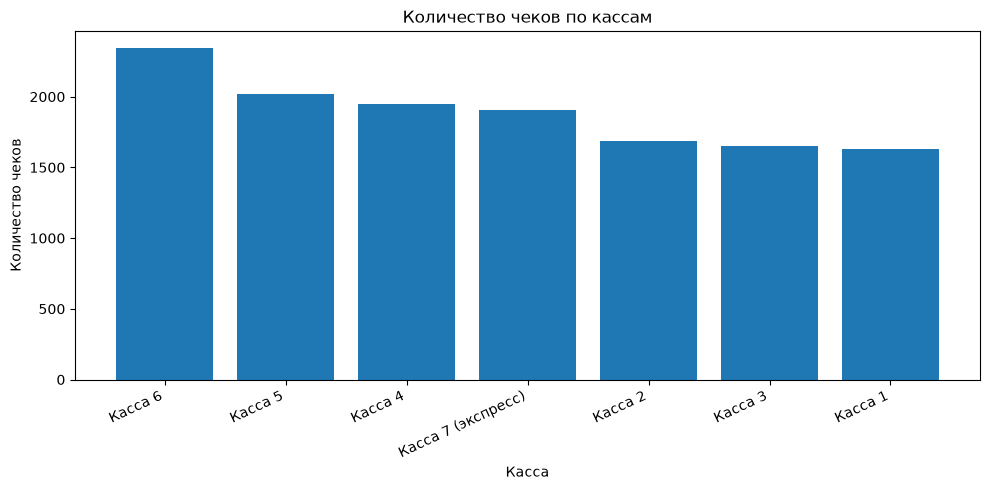

In [5]:
plot_df = cashier_summary.sort_values("receipts", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["cash_register"], plot_df["receipts"])
plt.title("Количество чеков по кассам")
plt.xlabel("Касса")
plt.ylabel("Количество чеков")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


## 5. Распределение размера корзины

Чтобы не ограничиваться средним значением, делю чеки на интервалы по числу товарных позиций и считаю долю каждого типа корзины по кассам.


In [6]:
bins = [0, 3, 10, 20, np.inf]
labels = ["1–3", "4–10", "11–20", "21+"]

basket_temp = checks.copy()
basket_temp["basket_group"] = pd.cut(
    basket_temp["positions"], bins=bins, labels=labels
)

basket_distribution = (
    pd.crosstab(
        basket_temp["cash_register"],
        basket_temp["basket_group"],
        normalize="index",
    ) * 100
).reindex(columns=labels, fill_value=0).round(1)

basket_distribution


basket_group,1–3,4–10,11–20,21+
cash_register,,,,
Касса 1,36.00,58.00,6.10,0.00
Касса 2,38.70,56.60,4.80,0.00
Касса 3,38.40,56.70,4.90,0.00
Касса 4,37.50,57.00,5.40,0.10
Касса 5,35.80,59.00,5.30,0.00
Касса 6,38.30,56.50,5.20,0.00
Касса 7 (экспресс),63.10,36.90,0.00,0.00


## 6. Пиковые дни и часы

Считаю среднее количество чеков для каждого сочетания дня недели и часового интервала. Среднее берётся по отдельным датам, чтобы один конкретный день не определял картину целиком.


In [7]:
by_date_hour = (
    checks.groupby(
        ["date", "weekday_num", "weekday", "hour", "period"],
        observed=True,
    )["receipt_id"]
    .nunique()
    .reset_index(name="receipts")
)

avg_hours = (
    by_date_hour.groupby(
        ["weekday_num", "weekday", "hour", "period"],
        observed=True,
    )["receipts"]
    .mean()
    .reset_index(name="average_receipts")
)

peak_periods = (
    avg_hours.sort_values(
        ["weekday_num", "average_receipts"], ascending=[True, False]
    )
    .groupby("weekday_num", as_index=False, observed=True)
    .head(1)
    .reset_index(drop=True)
)

peak_periods[["weekday", "period", "average_receipts"]]


,weekday,period,average_receipts
0,Понедельник,18–19,47.00
1,Вторник,18–19,46.75
2,Среда,18–19,48.75
3,Четверг,19–20,45.50
4,Пятница,18–19,51.50
5,Суббота,19–20,53.00
6,Воскресенье,18–19,52.50


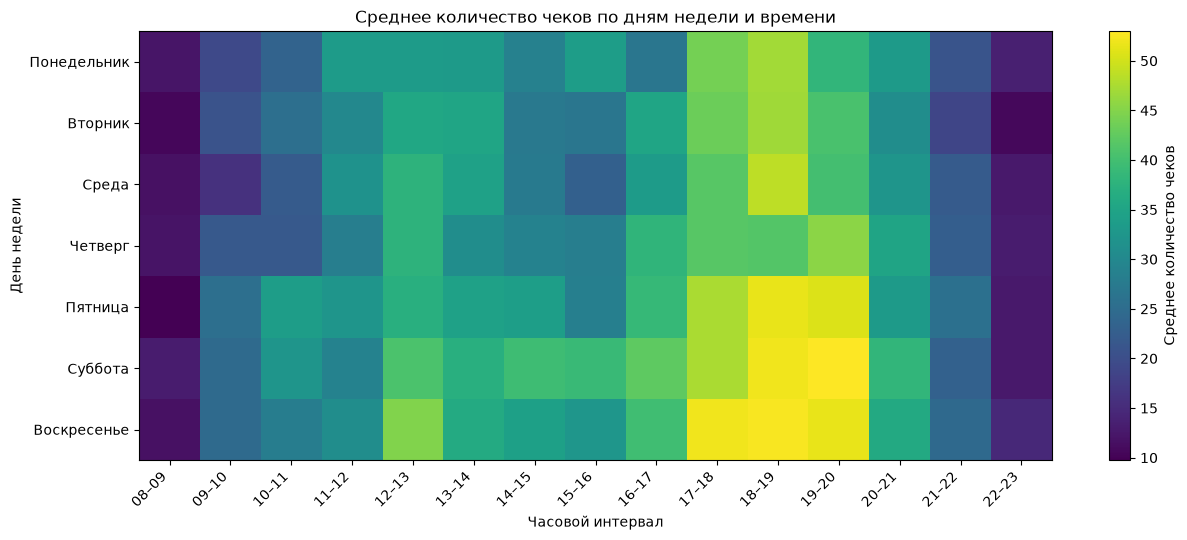

In [8]:
heat = avg_hours.pivot(
    index="weekday", columns="period", values="average_receipts"
).reindex(WEEKDAY_ORDER)

plt.figure(figsize=(13, 5.5))
image = plt.imshow(heat, aspect="auto")
plt.colorbar(image, label="Среднее количество чеков")
plt.xticks(range(len(heat.columns)), heat.columns, rotation=45, ha="right")
plt.yticks(range(len(heat.index)), heat.index)
plt.title("Среднее количество чеков по дням недели и времени")
plt.xlabel("Часовой интервал")
plt.ylabel("День недели")
plt.tight_layout()
plt.show()


## 7. Сценарная оценка необходимого количества кассиров

Модель не является нормативом — это управленческий сценарий. Для обычной кассы предполагается 25 секунд на чек + 4 секунды на товарную позицию, для экспресс-кассы — 18 + 3 секунды. Целевая загрузка сотрудника — 80% часа.


In [9]:
BASE_SECONDS_PER_CHECK = 25
SECONDS_PER_POSITION = 4
EXPRESS_BASE_SECONDS = 18
EXPRESS_SECONDS_PER_POSITION = 3
TARGET_UTILIZATION = 0.80

is_express = checks["cash_register"].eq(EXPRESS_REGISTER)
checks["estimated_service_sec"] = np.where(
    is_express,
    EXPRESS_BASE_SECONDS + checks["positions"] * EXPRESS_SECONDS_PER_POSITION,
    BASE_SECONDS_PER_CHECK + checks["positions"] * SECONDS_PER_POSITION,
)
checks["register_group"] = np.where(
    is_express, "Экспресс-касса", "Обычные кассы"
)

def staffing_matrix(data, group):
    selected = data[data["register_group"].eq(group)].copy()
    load = (
        selected.groupby(["date", "weekday", "hour"], observed=True)["estimated_service_sec"]
        .sum()
        .reset_index(name="load_sec")
    )
    avg = load.groupby(["weekday", "hour"], observed=True)["load_sec"].mean().reset_index()
    avg["cashiers_required"] = np.ceil(
        avg["load_sec"] / (3600 * TARGET_UTILIZATION)
    ).astype(int)
    avg["Время"] = avg["hour"].map(lambda h: f"{h:02d}:00")
    return (
        avg.pivot(index="Время", columns="weekday", values="cashiers_required")
           .reindex(columns=WEEKDAY_ORDER)
           .fillna(0)
           .astype(int)
    )

regular_staff = staffing_matrix(checks, "Обычные кассы")
regular_staff


weekday,Понедельник,Вторник,Среда,Четверг,Пятница,Суббота,Воскресенье
Время,,,,,,,
08:00,1,1,1,1,1,1,1
09:00,1,1,1,1,1,1,1
10:00,1,1,1,1,1,1,1
11:00,1,1,1,1,1,1,1
12:00,1,1,1,1,1,1,1
13:00,1,1,1,1,1,1,1
14:00,1,1,1,1,1,1,1
15:00,1,1,1,1,1,1,1
16:00,1,1,1,1,1,1,1


## 8. Товары в пиковые часы

Для каждого дня недели беру наиболее загруженный час и считаю, в скольких чеках встречается каждый товар. Это помогает понять состав спроса именно в момент максимальной нагрузки.


In [10]:
peak_hours = peak_periods[["weekday_num", "hour", "period"]].rename(
    columns={"hour": "peak_hour", "period": "peak_period"}
)

items = df.copy()
items["weekday_num"] = items["datetime"].dt.dayofweek
items["hour"] = items["datetime"].dt.hour

peak_items = items.merge(peak_hours, on="weekday_num", how="inner")
peak_items = peak_items[peak_items["hour"].eq(peak_items["peak_hour"])]
peak_items["weekday"] = peak_items["weekday_num"].map(WEEKDAY_MAP)

top_products = (
    peak_items.drop_duplicates(["receipt_id", "product"])
    .groupby(["weekday_num", "weekday", "peak_period", "product"])["receipt_id"]
    .nunique()
    .reset_index(name="receipts_with_product")
    .sort_values(["weekday_num", "receipts_with_product"], ascending=[True, False])
    .groupby("weekday_num", as_index=False)
    .head(10)
    .reset_index(drop=True)
)

top_products.head(20)


,weekday_num,weekday,peak_period,product,receipts_with_product
0,0,Понедельник,18–19,Вода 0.5 л,51
1,0,Понедельник,18–19,Вода 1.5 л,43
2,0,Понедельник,18–19,Газированный напиток,42
3,0,Понедельник,18–19,Хлеб,42
4,0,Понедельник,18–19,Шоколадный батончик,42
5,0,Понедельник,18–19,Жевательная резинка,40
6,0,Понедельник,18–19,Молоко,40
7,0,Понедельник,18–19,Шоколад,40
8,0,Понедельник,18–19,Чипсы,35
9,0,Понедельник,18–19,Яблоки,35


## 9. Проверка связи «товар — касса»

Одной разницы в частотах недостаточно: она может возникнуть случайно. Для каждой достаточно популярной позиции строится таблица сопряжённости и выполняется χ²-тест. Силу связи оцениваю через Cramér's V, а p-value корректирую методом Benjamini–Hochberg из-за множественных проверок.


In [11]:
def benjamini_hochberg(values):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]
    result = np.empty(len(values), dtype=float)
    result[order] = np.clip(ranked, 0, 1)
    return result

presence = df.drop_duplicates(["receipt_id", "product"])[
    ["receipt_id", "cash_register", "product"]
]
register_totals = checks.groupby("cash_register")["receipt_id"].nunique()
product_totals = presence.groupby("product")["receipt_id"].nunique()
candidates = product_totals[product_totals >= 35].index
registers = register_totals.index.tolist()

matrix = (
    presence[presence["product"].isin(candidates)]
    .groupby(["product", "cash_register"])["receipt_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=registers, fill_value=0)
)

tests = []
totals = register_totals.reindex(registers).to_numpy(dtype=float)
for product, row in matrix.iterrows():
    hits = row.to_numpy(dtype=float)
    misses = totals - hits
    table = np.vstack([hits, misses])
    chi2, p_value, _, expected = chi2_contingency(table)
    cramers_v = math.sqrt(chi2 / table.sum()) if table.sum() else 0
    tests.append((product, p_value, cramers_v, float(expected.min())))

tests_df = pd.DataFrame(
    tests, columns=["product", "p_value", "cramers_v", "min_expected"]
)
tests_df["adjusted_p"] = benjamini_hochberg(tests_df["p_value"].to_numpy())

tests_df.sort_values(["adjusted_p", "cramers_v"], ascending=[True, False]).head(15)


,product,p_value,cramers_v,min_expected,adjusted_p
6,Жевательная резинка,0.00,0.24,298.01,0.00
24,Шоколадный батончик,0.00,0.23,393.02,0.00
13,Орехи,0.00,0.21,232.60,0.00
22,Чипсы,0.00,0.20,344.90,0.00
12,Мятные драже,0.00,0.20,218.29,0.00
1,Булочка,0.00,0.19,281.96,0.00
9,Кофе растворимый,0.00,0.17,271.48,0.00
25,Энергетический напиток,0.00,0.17,308.37,0.00
5,Газированный напиток,0.00,0.17,401.17,0.00
23,Шоколад,0.00,0.16,334.78,0.00


## 10. Итоговые выводы

В рабочем проекте финальный блок должен отвечать не на вопрос «что посчитано», а на вопрос **«что из этого следует для бизнеса»**. Ниже выводы формируются из рассчитанных показателей, чтобы они обновлялись вместе с данными.


In [12]:
busiest_register = cashier_summary.iloc[0]
busiest_day = (
    checks.groupby("weekday", observed=True)["receipt_id"]
    .nunique()
    .sort_values(ascending=False)
    .index[0]
)
overall_peak = avg_hours.loc[avg_hours["average_receipts"].idxmax()]

print("Ключевые наблюдения")
print("-" * 60)
print(
    f"1. Наибольшая нагрузка по товарным позициям: {busiest_register['cash_register']} "
    f"({int(busiest_register['product_positions']):,} позиций)."
)
print(f"2. День с наибольшим количеством чеков в выборке: {busiest_day}.")
print(
    f"3. Максимальный средний поток наблюдается в {overall_peak['weekday']}, "
    f"интервал {overall_peak['period']} — {overall_peak['average_receipts']:.1f} чека в час."
)
print(
    "4. Расчёт персонала лучше использовать как сценарную оценку и калибровать "
    "по фактическому времени обслуживания."
)
print(
    "5. Статистические связи между товаром и кассой стоит интерпретировать "
    "только вместе с размером эффекта, а не по p-value отдельно."
)


Ключевые наблюдения
------------------------------------------------------------
1. Наибольшая нагрузка по товарным позициям: Касса 6 (11,581 позиций).
2. День с наибольшим количеством чеков в выборке: Суббота.
3. Максимальный средний поток наблюдается в Суббота, интервал 19–20 — 53.0 чека в час.
4. Расчёт персонала лучше использовать как сценарную оценку и калибровать по фактическому времени обслуживания.
5. Статистические связи между товаром и кассой стоит интерпретировать только вместе с размером эффекта, а не по p-value отдельно.


## 11. Экспорт результатов в Excel

Для передачи результата бизнес-пользователю таблицы можно собрать в один Excel-файл. В репозитории уже приложен пример готового отчёта в `output/`.


In [13]:
with pd.ExcelWriter(OUTPUT_PATH, engine="openpyxl") as writer:
    cashier_summary.to_excel(writer, sheet_name="Сводка по кассам", index=False)
    basket_distribution.reset_index().to_excel(writer, sheet_name="Корзины, %", index=False)
    peak_periods.to_excel(writer, sheet_name="Пиковые периоды", index=False)
    top_products.to_excel(writer, sheet_name="Топ товаров в пик", index=False)
    tests_df.sort_values("adjusted_p").to_excel(writer, sheet_name="Статистика", index=False)

print(f"Отчёт сохранён: {OUTPUT_PATH}")


Отчёт сохранён: C:\Users\User\data-and-development-portfolio\02-data-analysis\01-cashier-load\output\retail_analysis_report.xlsx


## Что демонстрирует кейс

- умение переводить бизнес-вопрос в измеримые показатели;
- подготовку и агрегацию транзакционных данных;
- работу с `pandas` на уровне `groupby`, `pivot`, `crosstab`;
- визуальный анализ временной нагрузки;
- сценарное моделирование;
- применение статистических тестов и контроль множественных сравнений;
- подготовку результата в формате, пригодном для передачи бизнес-пользователю.
